In [1]:
import pandas as pd 
path = r"/Users/maximeanno/Documents/ProjetPerso/EnergeticPricing/data/eCO2mix_RTE_Annuel-Definitif_2013.xlsx"

In [2]:
df = pd.read_excel(path)

df=df.rename(columns={"PÈrimËtre":"pays","PrÈvision J-1":"Prevision J-1","PrÈvision J":"Prevision J","NuclÈaire":"Nucleaire"})
df=df[df["pays"]=='France']
df= df[['Date', 'Heures', 'Consommation', 'Prevision J-1',
       'Prevision J', 'Fioul', 'Charbon', 'Gaz', 'Nucleaire', 'Eolien',
       'Solaire']]

In [4]:
sources =  ['Fioul', 'Charbon', 'Gaz', 'Nucleaire', 'Eolien', 'Solaire']

In [3]:
df["Prevision J"]-df[sources[0]]-df[sources[1]]-df[sources[2]]-df[sources[3]]-df[sources[4]]-df[sources[0]]

NameError: name 'sources' is not defined

In [5]:
df["Date"] = pd.to_datetime(df["Date"].astype(str) + " " +  df["Heures"].astype(str))

In [6]:
df = df.drop(columns="Heures")

In [7]:
df = df[df["Date"].dt.minute.isin([0,30])].reset_index(drop=True)
df

,Date,Consommation,Prevision J-1,Prevision J,Fioul,Charbon,Gaz,Nucleaire,Eolien,Solaire
0,2013-01-01 00:00:00,61194.0,60300.0,60200.0,482.0,0.0,3543.0,51412.0,4390.0,0.0
1,2013-01-01 00:30:00,59674.0,59500.0,58700.0,473.0,0.0,3448.0,50485.0,4178.0,0.0
2,2013-01-01 01:00:00,57877.0,57500.0,56700.0,472.0,0.0,3231.0,50070.0,4045.0,0.0
3,2013-01-01 01:30:00,57755.0,57800.0,57400.0,473.0,0.0,3240.0,50425.0,3967.0,0.0
4,2013-01-01 02:00:00,57243.0,57600.0,57200.0,472.0,0.0,3230.0,50247.0,3906.0,0.0
...,...,...,...,...,...,...,...,...,...,...
17515,2013-12-31 21:30:00,60770.0,59900.0,59600.0,455.0,0.0,2308.0,54619.0,3767.0,0.0
17516,2013-12-31 22:00:00,59958.0,59300.0,59000.0,455.0,0.0,2300.0,53978.0,3780.0,0.0
17517,2013-12-31 22:30:00,60990.0,61700.0,61300.0,454.0,0.0,2299.0,53265.0,3661.0,0.0
17518,2013-12-31 23:00:00,64252.0,64000.0,63600.0,455.0,0.0,2293.0,54481.0,3725.0,0.0


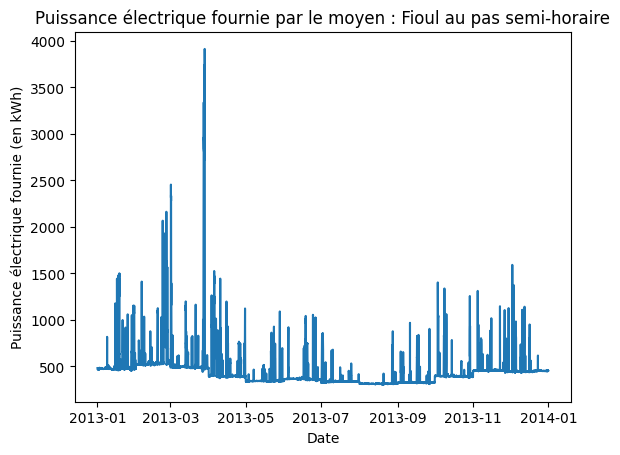

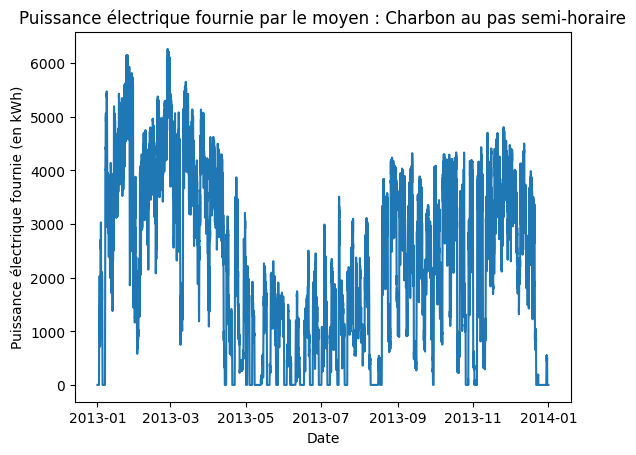

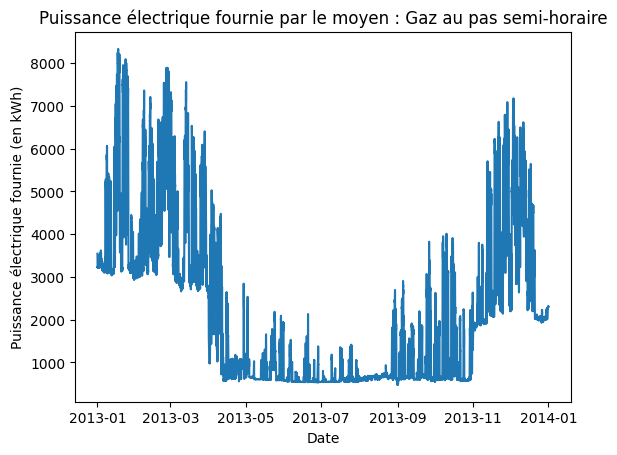

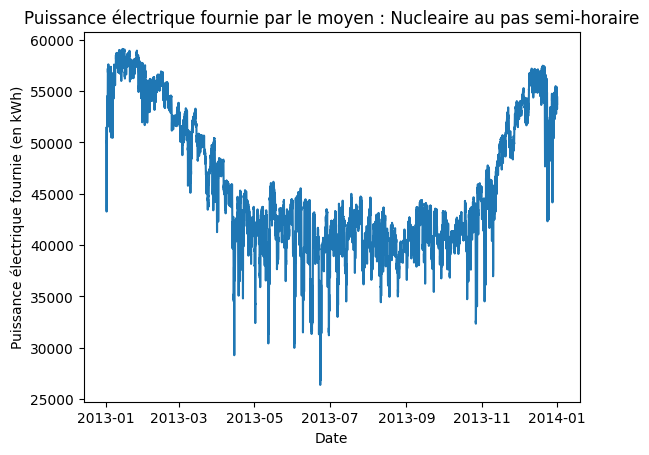

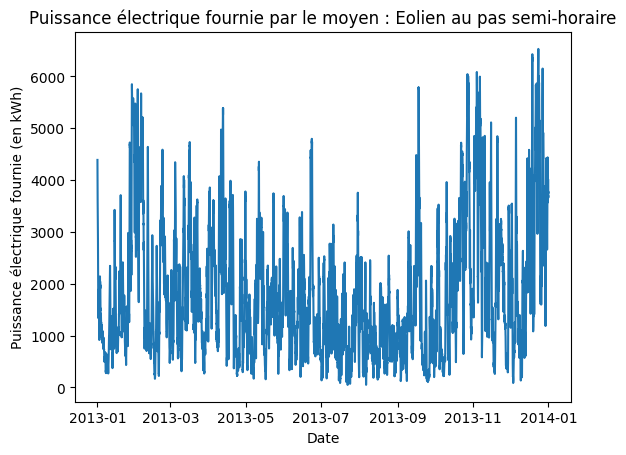

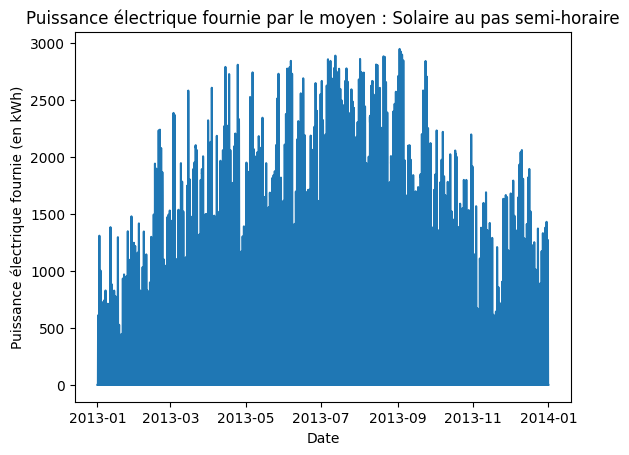

In [13]:
import matplotlib.pyplot as plt 

time = df["Date"]
for col_name in sources:
    source = df[col_name]

    plt.plot(time,source)
    plt.xlabel("Date")
    plt.ylabel("Puissance électrique fournie (en kWh)")
    plt.title(f"Puissance électrique fournie par le moyen : {col_name} au pas semi-horaire")
    plt.show()


In [15]:
df["Annee"]=df["Date"].dt.month

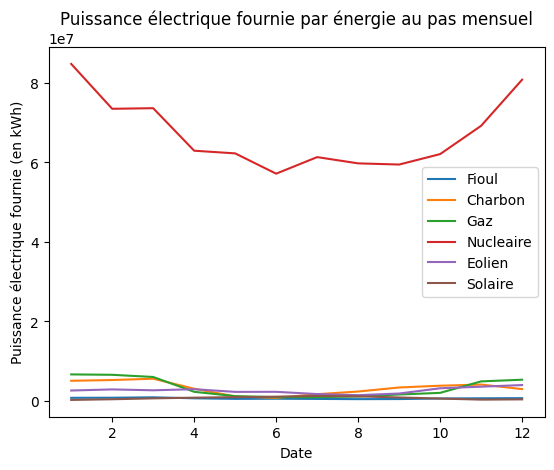

In [21]:
import matplotlib.pyplot as plt 

df_year = df.groupby("Annee")[sources].sum().reset_index()
time = df_year["Annee"]
for col_name in sources:

    source = df_year[col_name]

    plt.plot(time,source, label =f"{col_name}")
    plt.xlabel("Date")
    plt.ylabel("Puissance électrique fournie (en kWh)")

plt.legend()

plt.title(f"Puissance électrique fournie par énergie au pas mensuel")

plt.show()


In [22]:
sources

['Fioul', 'Charbon', 'Gaz', 'Nucleaire', 'Eolien', 'Solaire']

In [23]:
def new_cols_df(df,step):
    

    df["Step"]=df["Date"].dt.step
    return(df)

In [25]:
new_cols_df(df,"days")

AttributeError: 'DatetimeProperties' object has no attribute 'step'